# Collect Results for Paper Figures

This notebook is a paper-facing analysis notebook for the Sachs benchmark slice.

It assumes the following files already exist under `experiments/responses/sachs/`:
- `sachs_summary.csv`
- `sachs_all_systems.csv`
- `sachs_main_cohort.csv`

The notebook focuses on five analysis blocks:
1. the clean paper cohort,
2. classical-vs-LLM comparison,
3. prompt-representation sensitivity,
4. semantic-prior audit,
5. a separate Qwen/GRPO comparison on shared Sachs settings.

The main paper analysis uses `avg_*` metrics rather than consensus metrics.
All figures are saved under `experiments/responses/sachs/paper_figures/`.


In [54]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'experiments' and not (REPO_ROOT / 'responses').exists():
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / 'experiments').exists() and (REPO_ROOT.parent / 'experiments').exists():
    REPO_ROOT = REPO_ROOT.parent

GRAPH_NAME = 'sachs'
RESPONSES_DIR = REPO_ROOT / 'experiments' / 'responses' / GRAPH_NAME
RAW_SUMMARY_CSV = RESPONSES_DIR / 'sachs_summary.csv'
ALL_SYSTEMS_CSV = RESPONSES_DIR / 'sachs_all_systems.csv'
MAIN_COHORT_CSV = RESPONSES_DIR / 'sachs_main_cohort.csv'
FIG_DIR = RESPONSES_DIR / 'paper_figures'
TABLE_DIR = RESPONSES_DIR / 'paper_tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
PALETTE = {
    'summary_joint': '#1f77b4',
    'matrix': '#ff7f0e',
    'names_only': '#2ca02c',
    'ENCO': '#d62728',
    'PC': '#9467bd',
    'GES': '#8c564b',
}


In [55]:
raw_summary = pd.read_csv(RAW_SUMMARY_CSV)
all_systems = pd.read_csv(ALL_SYSTEMS_CSV)
main = pd.read_csv(MAIN_COHORT_CSV)

print('Raw summary:', raw_summary.shape)
print('All systems:', all_systems.shape)
print('Main cohort:', main.shape)

display(main.sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True))


FileNotFoundError: [Errno 2] No such file or directory: '/u/chenyuen0103/ENCO/experiments/responses/sachs/sachs_all_systems.csv'

## Main comparison tables

These tables are the paper-facing views for Sachs. The main analysis uses `avg_f1` and `avg_shd`.


In [56]:
main_table = main[[
    'system', 'system_kind', 'prompt_style', 'naming_regime',
    'obs_n', 'int_n', 'avg_f1', 'avg_shd', 'valid_rows', 'num_rows', 'source_file'
]].sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime'])

display(main_table)


NameError: name 'main' is not defined

In [57]:
repr_table = (
    main[
        (main['system'] == 'gpt-5-mini')
        & (main['prompt_style'].isin(['summary_joint', 'matrix']))
    ]
    .pivot_table(
        index=['obs_n', 'int_n', 'naming_regime'],
        columns='prompt_style',
        values=['avg_f1', 'avg_shd'],
        aggfunc='first',
    )
    .sort_index()
)

repr_table


NameError: name 'main' is not defined

In [140]:
AUDIT_PROMPT = 'summary_joint'

full_info = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == AUDIT_PROMPT)
].copy()

names_only = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == 'names_only')
].copy()

if names_only.empty:
    raise ValueError('No names_only row found in main cohort.')

names_only_row = names_only.iloc[0]
real = full_info[full_info['naming_regime'] == 'real'].copy()
anon = full_info[full_info['naming_regime'] == 'anonymized'].copy()

semantic_audit = real.merge(
    anon,
    on=['obs_n', 'int_n', 'prompt_style', 'system', 'system_kind'],
    suffixes=('_real', '_anon'),
)
semantic_audit['names_only_f1'] = float(names_only_row['avg_f1'])
semantic_audit['names_only_shd'] = float(names_only_row['avg_shd'])
semantic_audit['real_minus_anon_f1'] = semantic_audit['avg_f1_real'] - semantic_audit['avg_f1_anon']
semantic_audit['real_minus_names_only_f1'] = semantic_audit['avg_f1_real'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_names_only_f1'] = semantic_audit['avg_f1_anon'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_real_shd'] = semantic_audit['avg_shd_anon'] - semantic_audit['avg_shd_real']
semantic_audit = semantic_audit[[
    'obs_n', 'int_n',
    'avg_f1_real', 'avg_f1_anon', 'names_only_f1',
    'real_minus_anon_f1', 'real_minus_names_only_f1', 'anon_minus_names_only_f1',
    'avg_shd_real', 'avg_shd_anon', 'names_only_shd', 'anon_minus_real_shd'
]].sort_values(['obs_n', 'int_n'])

semantic_audit


,obs_n,int_n,avg_f1_real,avg_f1_anon,names_only_f1,real_minus_anon_f1,real_minus_names_only_f1,anon_minus_names_only_f1,avg_shd_real,avg_shd_anon,names_only_shd,anon_minus_real_shd
0,0,100,0.431748,0.356080,0.496322,0.075668,-0.064573,-0.140241,22.6,53.8,14.6,31.2
1,0,200,0.413266,0.422158,0.496322,-0.008891,-0.083055,-0.074164,25.0,40.0,14.6,15.0


## Main paper figures

The figures below correspond to the main benchmark story:
- representation sensitivity,
- semantic-prior audit,
- classical-vs-LLM budget curves.


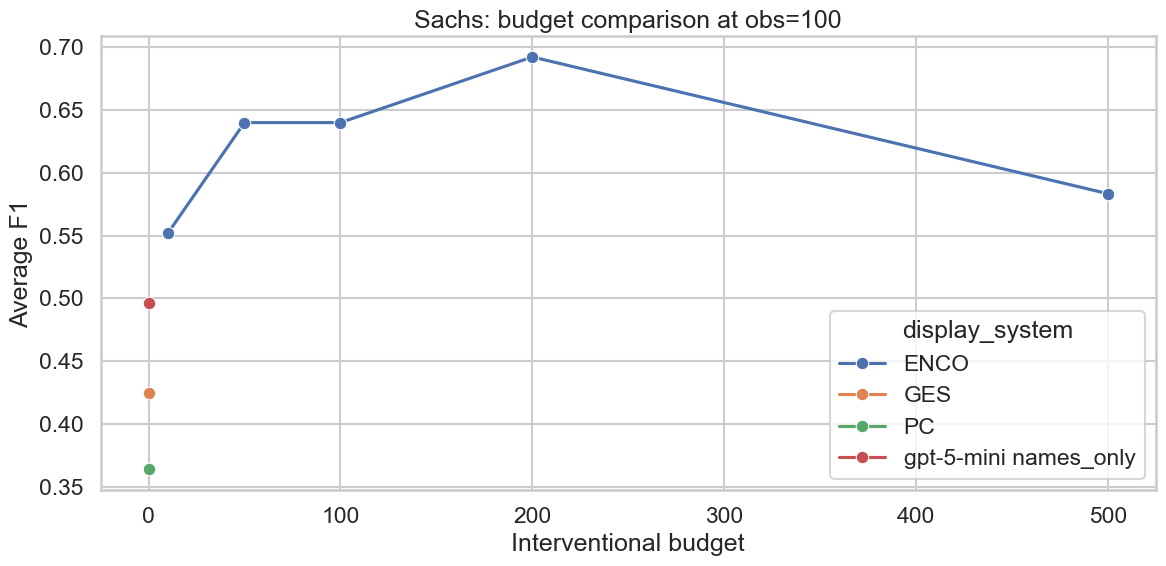

In [141]:
curve_df = main[
    main['system'].isin(['ENCO', 'PC', 'GES', 'gpt-5-mini'])
].copy()
curve_df = curve_df[
    (curve_df['prompt_style'].isin(['classical', 'summary_joint']))
    | ((curve_df['system'] == 'gpt-5-mini') & (curve_df['prompt_style'] == 'names_only'))
].copy()
curve_df['display_system'] = curve_df.apply(
    lambda r: r['system'] if r['system_kind'] == 'classical' else (
        'gpt-5-mini summary_joint' if r['prompt_style'] == 'summary_joint' else 'gpt-5-mini names_only'
    ),
    axis=1,
)

obs_focus = 100
plot_curve = curve_df[(curve_df['obs_n'] == obs_focus) | (curve_df['prompt_style'] == 'names_only')].copy()
plot_curve.loc[plot_curve['prompt_style'] == 'names_only', 'int_n'] = 0

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=plot_curve.sort_values(['display_system', 'int_n']),
    x='int_n', y='avg_f1', hue='display_system', marker='o', ax=ax,
)
ax.set_title(f'Sachs: budget comparison at obs={obs_focus}')
ax.set_ylabel('Average F1')
ax.set_xlabel('Interventional budget')
fig.tight_layout()
fig.savefig(FIG_DIR / f'sachs_budget_curve_obs{obs_focus}_avg_f1.png', dpi=220, bbox_inches='tight')
plt.show()


In [142]:
raw_summary[(raw_summary['prompt_style'] == 'enco') & (raw_summary['obs_n'] == 5000) & (raw_summary['int_n'] == 200)]

,anonymize,avg_FN,avg_FP,avg_TN,avg_TP,avg_accuracy,avg_accuracy_sd,avg_accuracy_se,avg_f1,avg_f1_sd,avg_f1_se,avg_orientation_FN,avg_orientation_TP,avg_orientation_accuracy,avg_orientation_eval_pairs,avg_precision,avg_precision_sd,avg_precision_se,avg_recall,avg_recall_sd,avg_recall_se,avg_shd,avg_shd_sd,avg_shd_se,brier,brier_skeleton,causal_rules,col_order,consensus_K,consensus_accuracy,consensus_f1,consensus_num_edges,consensus_orient_acc,consensus_precision,consensus_recall,consensus_shd,consensus_tau,context_exceeded_any,context_exceeded_by_error_rows,context_exceeded_by_tokens_rows,context_window,dataset,evaluated,format_ok_rows,format_rate,format_scored_rows,give_steps,given_edge_count,given_edge_frac,given_edges,int_n,is_names_only,model,nhd_ci95_high,nhd_ci95_low,nhd_consensus,nhd_iqr,nhd_mean,nhd_mean_se,nhd_ratio_ci95_high,nhd_ratio_ci95_low,nhd_ratio_consensus,nhd_ratio_iqr,nhd_ratio_mean,nhd_ratio_mean_se,nhd_ratio_sd,nhd_sd,num_pred_edges,num_pred_edges_sd,num_pred_edges_se,num_rows,obs_n,prompt_style,prompt_tokens_max,prompt_tokens_mean,prompt_tokens_missing_rows,prompt_tokens_rows,response_csv,row_order,shuffles_per_graph,spread_n,summary_json,tau,true_num_edges,valid_rows,var_accuracy_ci95_high,var_accuracy_ci95_low,var_accuracy_iqr,var_accuracy_sd,var_f1_ci95_high,var_f1_ci95_low,var_f1_iqr,var_f1_sd,var_num_pred_edges_ci95_high,var_num_pred_edges_ci95_low,var_num_pred_edges_iqr,var_num_pred_edges_sd,var_precision_ci95_high,var_precision_ci95_low,var_precision_iqr,var_precision_sd,var_recall_ci95_high,var_recall_ci95_low,var_recall_iqr,var_recall_sd,var_shd_ci95_high,var_shd_ci95_low,var_shd_iqr,var_shd_sd
538,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,sachs,1,NaN,NaN,NaN,0,NaN,NaN,NaN,200.0,0,ENCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5000.0,enco,NaN,NaN,NaN,NaN,experiments/responses/sachs/predictions_obs500...,random,NaN,1,experiments/responses/sachs/predictions_obs500...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
pretty_model = {
    'ENCO': 'ENCO',
    'gpt-5-mini': 'GPT-5-mini',
    'gpt-5.2-pro': 'GPT-5.2-pro',
    'Qwen3-4B-Thinking-2507': 'Qwen3-4B base',
    # 'checkpoint-4': 'checkpoint-4',
    # 'sft': 'SFT',
    'grpo_v2_cancer_eq': 'GRPO v2 cancer+eq',
    # 'grpo_sachs_mix_onthefly_mp2': 'GRPO mix',
    # 'grpo_sft_8192': 'GRPO SFT-8192',
    # 'grpo_sft_8192_cd_focus': 'GRPO SFT-8192 CD',
    # 'grpo_sft_8192_from4096': 'GRPO from4096',
    # 'stage_3_obs100_int0_bootstrap': 'stage3 bootstrap',
    # 'stage_3_obs100_int0_graph_scaled': 'stage3 graph-scaled',
    # 'stage_3_obs100_int0_retuned': 'stage3 retuned',
}

# Full-information runs
full_info = raw_summary[
    raw_summary["model"].isin(pretty_model.keys())
    & (raw_summary["obs_n"].fillna(-1) == 5000)
    & (raw_summary["int_n"].fillna(-1) == 200)
    & (raw_summary["prompt_style"].isin(["summary_joint", "matrix", "enco"]))
    & (raw_summary["response_csv"].str.contains("thinktags", na=False))
    # & (raw_summary["response_csv"].str.contains("cothint", na=False))
].copy()



# Name-only control
name_only = raw_summary[
    raw_summary["model"].isin(pretty_model.keys())
    # & (raw_summary["obs_n"].fillna(-1) == 0)
    # & (raw_summary["int_n"].fillna(-1) == 0)
    & (raw_summary["prompt_style"] == "names_only")
    & (raw_summary["response_csv"].str.contains("thinktags", na=False))
    # & (raw_summary["response_csv"].str.contains("cothint", na=False))
].copy()

full_info["display_model"] = full_info["model"].map(pretty_model)
name_only["display_model"] = name_only["model"].map(pretty_model)

full_info = full_info[full_info["display_model"].notna()].copy()
name_only = name_only[name_only["display_model"].notna()].copy()

full_info["setting"] = full_info["prompt_style"].astype(str)
name_only["setting"] = "name only"
# Put ENCO under one bar category instead of separate summary_joint/matrix bars
full_info["setting"] = full_info["prompt_style"].replace({
    "summary_joint": "summary_joint",
    "matrix": "matrix",
    "enco": "ENCO",
})

full_info["display_model"] = pd.Categorical(
    full_info["display_model"],
    categories=list(pretty_model.values()),
    ordered=True,
)
name_only["display_model"] = pd.Categorical(
    name_only["display_model"],
    categories=list(pretty_model.values()),
    ordered=True,
)

plot_real = pd.concat(
    [
        full_info[full_info["anonymize"].fillna(0).astype(int) == 0],
        name_only,
    ],
    ignore_index=True,
)

plot_anon = full_info[
    full_info["anonymize"].fillna(0).astype(int) == 1
].copy()

plot_real["setting"] = pd.Categorical(
    plot_real["setting"],
    categories=["summary_joint", "matrix", "ENCO", "name only"],
    ordered=True,
)
plot_anon["setting"] = pd.Categorical(
    plot_anon["setting"],
    categories=["summary_joint", "matrix", "ENCO"],
    ordered=True,
)


In [1]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real,
    x="setting",
    y="avg_f1",
    hue="display_model",
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (real names)")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Average F1")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon,
    x="setting",
    y="avg_f1",
    hue="display_model",
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (anonymized names, obs=5000, int=200)")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Average F1")
axes[1].tick_params(axis="x", rotation=30)

axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real,
    x="setting",
    y="avg_shd",
    hue="display_model",
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (real names)")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Average SHD")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon,
    x="setting",
    y="avg_shd",
    hue="display_model",
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (anonymized names, obs=5000, int=200)")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Average SHD")
axes[1].tick_params(axis="x", rotation=30)

axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()


NameError: name 'plt' is not defined

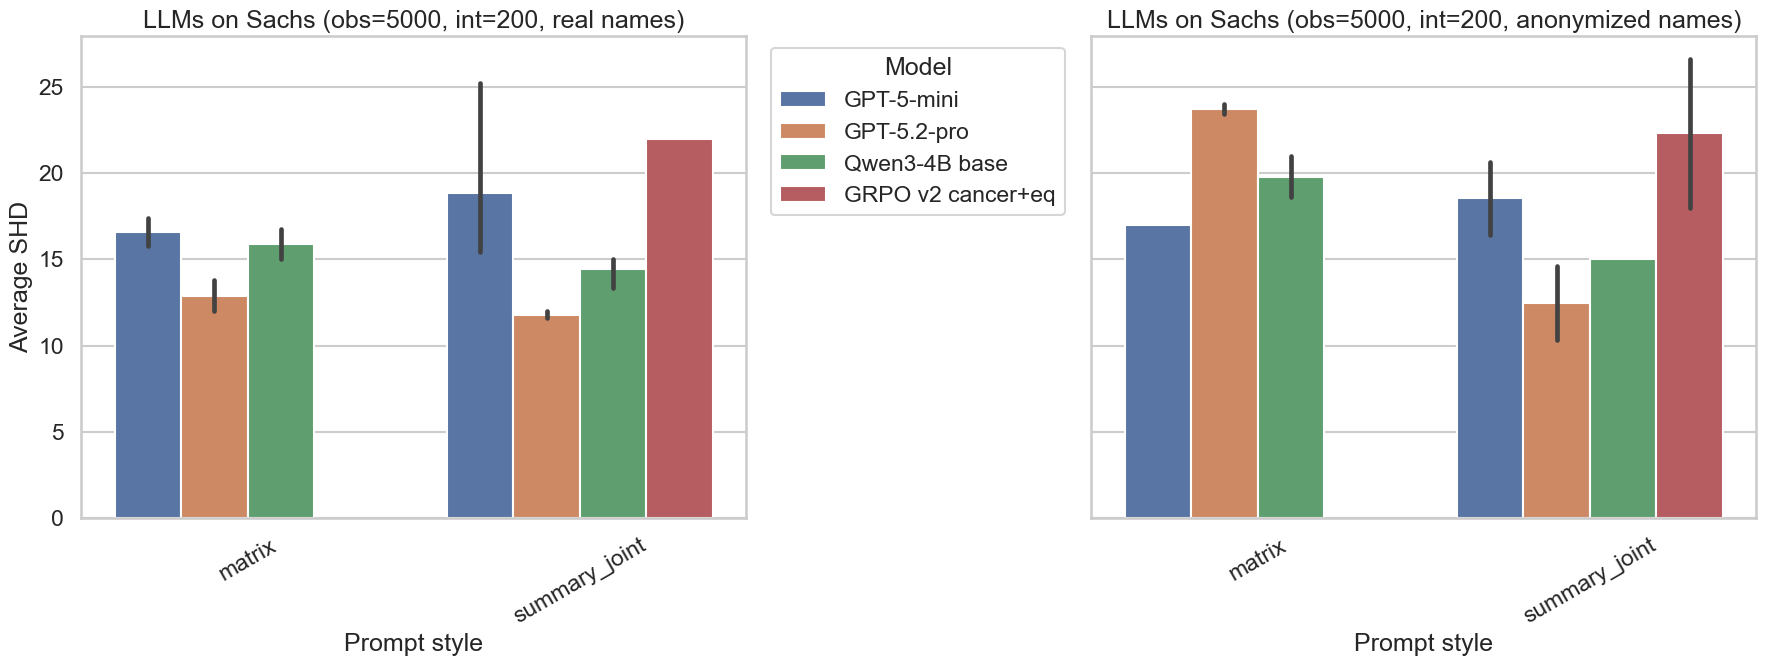

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real,
    x="setting",
    y="avg_shd",
    hue="display_model",
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (obs=5000, int=200, real names)")
axes[0].set_xlabel("Prompt style")
axes[0].set_ylabel("Average SHD")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon,
    x="setting",
    y="avg_shd",
    hue="display_model",
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (obs=5000, int=200, anonymized names)")
axes[1].set_xlabel("Prompt style")
axes[1].set_ylabel("Average SHD")
axes[1].tick_params(axis="x", rotation=30)

axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()


## Qwen / GRPO comparison

This section is separate from the main benchmark cohort. It compares the pretrained Qwen model
against the SFT / GRPO variants on the Sachs settings they actually share.

By default, it uses the strongest shared slice we currently have in this folder:
- `names_only` with `p5`, and
- `thinktags` runs at `obs=0`, `int=200` for `summary_joint` and `matrix`.


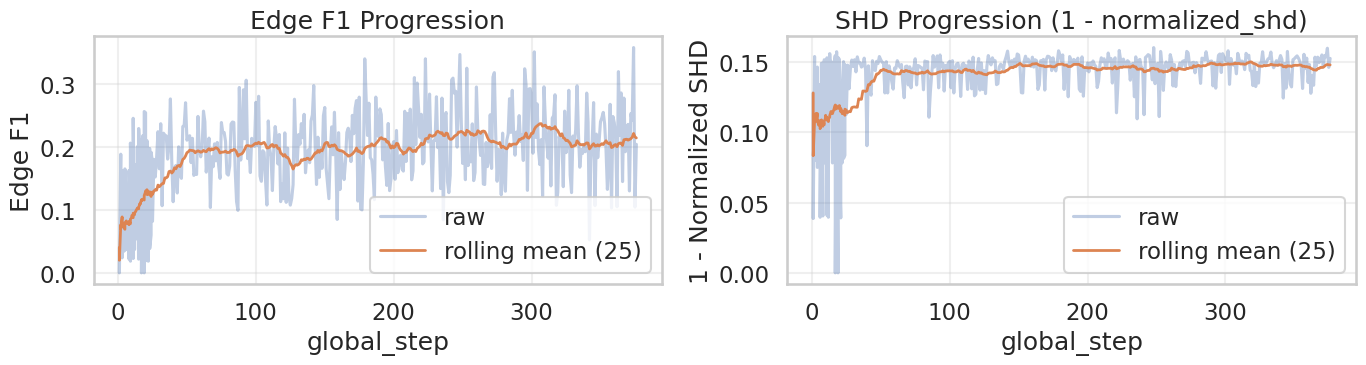

In [64]:
import json
import pandas as pd
import matplotlib.pyplot as plt

path = "./checkpoints/causal_grpo_sachs_v1/grpo_log/train_metrics.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows).sort_values("global_step").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Edge F1
y_edge = "rewards/cd_edge_f1_reward/mean"
ax1.plot(df["global_step"], (df[y_edge]/0.4), alpha=0.35, label="raw")
smooth_edge = (df[y_edge]/0.4).rolling(window=25, min_periods=1).mean()
ax1.plot(df["global_step"], smooth_edge, linewidth=2, label="rolling mean (25)")
ax1.set_xlabel("global_step")
ax1.set_ylabel("Edge F1")
ax1.set_title("Edge F1 Progression")
ax1.legend()
ax1.grid(True, alpha=0.3)

# SHD (lower is better)
y_shd = "rewards/cd_low_shd_reward/mean"
ax2.plot(df["global_step"], df[y_shd], alpha=0.35, label="raw")
smooth_shd = df[y_shd].rolling(window=25, min_periods=1).mean()
ax2.plot(df["global_step"], smooth_shd, linewidth=2, label="rolling mean (25)")
ax2.set_xlabel("global_step")
ax2.set_ylabel("1 - Normalized SHD")
ax2.set_title("SHD Progression (1 - normalized_shd)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()